# <br>

<img src="logo_UNSAM.jpg" align="right" width="180" /> 

<br><br><br>

<h3 align="center">Análisis y Procesamiento de Señales</h3>

<h1 align="center"><b>TS4 - Primeras nociones de estimación espectral</b></h1>
<h3 align="center">Paloma Ribnikar Diaz</h3>


## Objetivos
$\quad$ El objetivo principal que presenta este trabajo semanal es el de estudiar una señal que viene contaminada por un ruido aleatorio y con desintonías desconocidas.
$\quad$ Para ello, el objeto fundamental de estudio van a ser los estimadores de amplitud y de frecuencia. En adición, se analizan parámetros estadísticos como el sesgo, varianza y media muestral sobre 200 realizaciones de la señal, evaluando el comportamiento para distintos niveles de SNR (3 dB y 10 dB) y aplicando distintas ventanas.

## Introducción

$\quad$ En los trabajos semanales anteriores hemos trabajado con señales ideales de parámetros fijos y conocidos. Sin embargo, al conectar un sensor u osciloscopio a un sistema físico real, nos encontramos con que la señal medida viene contaminada por ruido aleatorio y con desintonías frecuenciales desconocidas respecto a la grilla de muestreo.

$\quad$ Para modelar esta situación, en esta TS4 analizamos la siguiente señal discreta:

$$x[n] = a_0 \cdot \sin(\Omega_1 \cdot n) + n_a[n]$$

donde:
* **Amplitud verdadera ($a_0 = \sqrt{2}$):** Seleccionada de este modo para garantizar una potencia de señal unitaria ($P_s = 1 \text{ W}$).
* **Frecuencia digital ($\Omega_1 = \Omega_0 + f_r \cdot \frac{2\pi}{N}$):** Donde $\Omega_0 = \frac{\pi}{2} \text{ rad/muestra}$ representa la frecuencia digital central (correspondiente al bin $k_0 = N/4 = 250$ para $N = 1000$ muestras y $f_s = 1000 \text{ Hz}$).
* **Desintonía aleatoria ($f_r \sim \mathcal{U}(-2, 2)$):** Variable aleatoria uniforme que contempla la incertidumbre frecuencial. Al no caer exactamente en un bin entero de la DFT, esta desintonía activa los fenómenos de **desparramo espectral** (*spectral leakage*) y **pérdida por festoneado** (*scalloping loss*), explicados en la TS3.
* **Ruido blanco gaussiano ($n_a \sim \mathcal{N}(0, \sigma^2)$):** Ruido de media nula ($\mu = 0$) cuya varianza $\sigma^2$ se ajusta en función de la relación señal a ruido deseada ($\text{SNR} = 3 \text{ dB}$ y $10 \text{ dB}$).


### Concepto de Estimador y Experimento de Monte Carlo

$\quad$ Un **estimador ($\hat{\theta}$)** es una función o algoritmo matemático que procesa las $N$ muestras ruidosas registradas para inferir el valor verdadero pero desconocido de un parámetro ($\theta$). Dado que los datos observados son estocásticos, el estimador en sí mismo resulta ser una variable aleatoria.

$\quad$ Para evaluar cuantitativamente la calidad de los estimadores, recurrimos a un **experimento de Monte Carlo** ejecutando $R = 200$ realizaciones independientes. Sobre dicho conjunto estudiamos dos propiedades estadísticas fundamentales:

1. **Sesgo ($s_a$ / bias):** Mide el error sistemático o la desviación media del estimador respecto al valor verdadero real. Si $s_a = 0$, se dice que el estimador es **insesgado**:
$$
s_a = \text{sesgo}(\hat{\theta}) = E[\hat{\theta}] - \theta
$$

2. **Varianza ($v_a$ / variance):** Mide la dispersión o falta de repetibilidad de las estimaciones alrededor de su propia media debido a la presencia de ruido:
$$
v_a = \text{var}(\hat{\theta}) = E\left[\left(\hat{\theta} - E[\hat{\theta}]\right)^2\right]
$$

Un estimador ideal es insesgado y de mínima varianza.


### Estimadores implementados

$\quad$ En esta tarea diseñamos y evaluamos dos estimadores principales a partir de la Transformada Discreta de Fourier (DFT):

* **Estimador de Amplitud ($\hat{a}_1$):** Evalúa el módulo del espectro unilateral en la frecuencia digital central de referencia $\Omega_0$:
$$
\hat{a}_1(i) = \left| X_{w_i}(\Omega_0) \right| = \left| \mathcal{F}\{ x[n] \cdot w_i[n] \} \right|_{\Omega_0}
$$
  *(En el código, para evitar que la ventana atenúe la amplitud y ajustar el espectro unilateral a volts pico, se normaliza dividiendo por la **ganancia coherente** $W_0 = \sum_{n=0}^{N-1} w_i[n]$ y multiplicando por 2)*.

* **Estimador de Frecuencia ($\hat{\Omega}_1$):** Busca la ubicación del bin de módulo máximo absoluto en la mitad positiva del espectro $\hat{k} = \arg\max_{\Omega} \left| X_{w_i}(\Omega) \right|$. A partir de dicho índice se obtiene la frecuencia digital estimada en rad/muestra mediante:
$$
\hat{\Omega}_1(i) = \hat{k} \cdot \frac{2\pi}{N}
$$
  *(o equivalentemente a frecuencia analógica en Hz mediante $f = \frac{\hat{k} \cdot f_s}{N}$, relacionándose ambas por $\Omega = 2\pi \frac{f}{f_s}$)*.


### El Rol de las Ventanas y el Trade-off Espectral

$\quad$ Dado que la ventana Rectangular sufre fuertemente de festoneado cuando la frecuencia se desplaza ($f_r \neq 0$), se analiza el *trade-off* espectral al aplicar distintas ventanas de ponderación (**Flat-Top, Blackman-Harris y Hann**). 

$\quad$ El comportamiento de sus lóbulos define el compromiso entre la resolución en frecuencia (ancho del lóbulo principal) y la contaminación espectral (atenuación de lóbulos secundarios):

* **Rectangular:** Tiene el lóbulo principal más angosto, lo que otorga la mayor resolución en frecuencia. Sin embargo, sus lóbulos laterales son altos ($\approx -13 \text{ dB}$), por lo que presenta un fuerte desparramo espectral y mayor pérdida por festoneado (*scalloping loss*) cuando la frecuencia no cae exactamente en un bin.
* **Flat-Top:** Diseñada específicamente para medir amplitudes con mínimo error. Posee un lóbulo central de techo plano y lóbulos laterales extremadamente atenuados ($\approx -93 \text{ dB}$), eliminando la pérdida por festoneado a costa de una menor resolución en frecuencia.
* **Blackman–Harris:** Presenta lóbulos laterales muy atenuados ($\approx -92 \text{ dB}$), disminuyendo notablemente el desparramo espectral lejano. Su lóbulo principal es algo más angosto que el de la Flat-Top, logrando un compromiso equilibrado entre baja contaminación espectral y una resolución aceptable.
* **Hann:** Sus lóbulos laterales presentan una atenuación cercana a $-31 \text{ dB}$ y un lóbulo principal de ancho moderado. Es una opción equilibrada que reduce el desparramo espectral respecto a la Rectangular sin ensanchar en exceso el lóbulo principal.

## Desarrollo y Análisis

## Código en Python

### Librerías y Definiciones

$\quad$ En este apartado se definen las librerías necesarias, incorporando, a diferencia de las TS anteriores, el módulo "scipy.signal.windows" para generar las funciones de ventaneo que permitirán analizar el comportamiento espectral bajo distintas condiciones.

$\quad$ Respecto a los parámetros, algunos ya fueron estudiados en los trabajos semanales anteriores, mientras que otros son específicos de esta TS4 —como la frecuencia digital central $\Omega_0 = \pi/2 \text{ rad/muestra}$, la cual se define directamente en radianes por muestra para evitar incoherencias de unidades al evaluar el argumento del seno ($[\text{rad/muestra}] \times [\text{muestras}] = [\text{rad}]$)—. 

$\quad$ Finalmente, se inicializan los diccionarios de almacenamiento donde se guardarán las realizaciones de la FFT y los estimadores obtenidos para cada escenario de SNR ($10\text{ dB}$ y $3\text{ dB}$) y así presentar los datos de forma organizada al finalizar.

In [2]:
# -*- coding: utf-8 -*-
"""
Created on Tue Sep 15 09:00:55 2026

@author: ribni
"""

#%% LIBRERIAS

import numpy as np
import matplotlib.pyplot as plt
import scipy.signal.windows as sg

#%% DEFINICIONES

""" Parametros fijos del ejercicio """
# ADC - Cuantizador
fs = 1000 # Frecuencia de muestreo (Hz) --> FNyquist = fs/2 = 500Hz
N = 1000 # Cantidad de muestras (ancho de ventana)

# Señal senoidal
a0 = np.sqrt (2)  # Amplitud pico (volts) / P = 1 Watt --> Normalizada
dc = 0  # Componente continua / offset inicial (volts)
ff = fs/N  # Frecuencia de la senoidal (Hz)
ph = 0  # Fase inicial (rad)

""" Específicos de TS4 """
# Frecuencia digital central (rad/muestra) -> equivale a k0 = N/4 = 250 Hz
omega_0 = np.pi / 2 # (rad/muestra)

# Var. dinámicas
omega_1 = omega_0 # Frecuencia c/ desintonía aleatoria (fr)
n_a = None # Vector de ruido blanco gaussiano (N muestras)

# Para guardar los 200 resultados de cada ventana
estimaciones_a1 = {}
estimaciones_w1 = {}
fft_10dB = {}

estimaciones_a1_3dB = {}
estimaciones_w1_3dB = {}
fft_3dB = {}

### Funciones

$\quad$ En este apartado se definen las funciones empleadas para el desarrollo del trabajo. La mayoría corresponden a funciones ya utilizadas en trabajos anteriores, incorporando en esta TS4 la función func_omega_1 (para calcular la frecuencia desintonizada $\Omega_1$), la función para calcular la varianza del ruido según la SNR, y la definición del diccionario con las cuatro ventanas de ponderación (Rectangular, Flat-Top, Blackman-Harris y Hann).

In [3]:
#%% FUNCIONES

""" Funcion señal senoidal discretizada """
def mi_funcion_sen(a0 = a0, dc = n_a, omega_1 = omega_1, nn = N):
    
    # Rango de 0 a N-1 --> tiempo discreto
    tt =  (np.arange (nn) / fs) #np.arange para generar un vector de N nros
    
    # Señal Senoidal
    xx = a0 * np.sin (omega_1 * np.arange(nn)) + dc
    
    return tt, xx

""" Secuencia aleatoria de ruido Gaussiano con media 0 y la varianza especificada """
def generar_ruido_gaussiano(varianza=0.1, loc=0.0, size=1000):

    # Calculo la desv. estandar (sigma) haciendo la raiz de la varianza de entrada
    sigma_nq = np.sqrt(varianza)
    
    # Genero el vector de ruido con la distribucion normal (Gaussiana)
    n_a = np.random.normal(loc=loc, scale=sigma_nq, size=size)
    
    return n_a

# Función auxiliar para calcular la varianza del ruido en función de la SNR
def calcular_varianza_ruido(snr_db, P_s=1.0):
    return P_s / (10**(snr_db / 10))

""" PSD: Densidad Espectral de Potencia calibrada en dB """
def calcular_psd_db (x, N):
    
    # Formula de potencia --> elevo al cuadrado y divido por 2 para tener Watts
    potencia_lineal = (np.abs(x))**2 / 2
    
    # paso a decibeles con escala log y aplicando "parche"
    psd_dB = 10 * np.log10(potencia_lineal + 1e-12)
    
    return psd_dB

def func_omega_1 (omega_0, fr, N):
    
    omega_1 = omega_0 + fr * (2*(np.pi)/N)
    
    return omega_1

''' VENTANAS '''
ventanas = {
    'Rectangular': np.ones(N),
    'Flat-Top': sg.flattop(N),
    'Blackman-Harris': sg.blackmanharris(N),
    'Hann': sg.hann(N),
}

### Script

$\quad$ En una primera instancia, se definen los ejes de frecuencia que se emplearán luego para los gráficos de los dominios espectrales:

In [4]:
#%% SCRIPT
# Eje de frecuencia genérico para todas las FFT
ff_vector = np.fft.fftfreq(N, d=1 / fs)
ff_vector_pos = ff_vector[:N//2] # Solo tomo los valores positivos (simetrico)


$\quad$ Definimos la señal senoidal ruidosa para un nivel de $\text{SNR} = 10\text{ dB}$, incorporando la desintonía aleatoria $f_r$ y calculando su FFT.

In [5]:
''' Parámetros necesarios para definir la función senoidal '''
# Ruido Gaussiano
varianza_n_a_10dB = calcular_varianza_ruido(snr_db = 10, P_s = 1.0)
n_a_10dB = generar_ruido_gaussiano(varianza = varianza_n_a_10dB, loc = 0.0, size = 1000)

# Desintonía fr
fr_a = np.random.uniform(low = -2, high = 2) # No le paso size = N asi genera UN SOLO número aleatorio entre -2 y 2
omega_1_10dB = func_omega_1 (omega_0, fr_a, N)

''' Función senoidal '''
# Senoidal limpia (dc = 0)
tt, xx_limpia = mi_funcion_sen(a0 = a0, dc = 0, omega_1 = omega_1_10dB, nn = N)  

# Senoidal + ruido
xx = xx_limpia + n_a_10dB

# FFT de la  señal ruidosa
xx_fft = np.fft.fft(xx)

$\quad$ Para evaluar el comportamiento estadístico de los estimadores, necesitamos generar $R = 200$ realizaciones independientes de la señal. Para evitar el uso de bucles for (lo cual ralentizaría el cómputo), utilizamos la técnica de **broadcasting** de NumPy. De esta manera, construimos en un solo paso vectorizado una matriz de tamaño $(N \times R) = (1000 \times 200)$, donde cada columna representa una realización completa:
* **Vector de tiempo discreto (n_col):** Se define como un vector columna de dimensión $(N \times 1)$ con los índices de muestra $n = 0, 1, \dots, N-1$.
* **Vector de frecuencias aleatorias (omega_1_mat):** Se define como un vector fila de dimensión $(1 \times R)$ que contiene las $200$ frecuencias desintonizadas $\Omega_1$ generadas para cada realización.
* **Matriz de senoidales puras (xx_sen_mat):** Al multiplicar n_col * omega_1_mat, NumPy expande automáticamente ambos vectores generando una matriz de $(N \times R)$ con el argumento de la senoidal para cada muestra y realización, multiplicada por la amplitud verdadera $a_0$.
* **Matriz de ruido (n_a_mat) y señal contaminada (xx_mat):** Generamos la matriz de ruido blanco gaussiano de tamaño $(N \times R)$ configurada para una $\text{SNR} = 10\text{ dB}$ y se la sumamos a la matriz de senoidales puras para obtener las $200$ señales ruidosas.

In [6]:
''' MATRIZ MEDIANTE BROADCASTING ''' 
# Defino los tamaños de la matriz
R = 200  # 200 columnas / realizaciones / experimentos
N = 1000  # 1000 filas / muestras de tiempo

# vector columna de tiempo discreto (1000, 1) -> se para en vertical
n_col = np.arange(N).reshape(N, 1)


# genero las 200 frecuencias desintonizadas en horizontal (1, 200)
fr = np.random.uniform(-2, 2, size = R) # 200 números aleatorios (uno para cada experimento)
omega_1_mat = func_omega_1 (omega_0, fr, N)
omega_1_mat = omega_1_mat.reshape(1, R) # Fila horizontal (1, 200)


# Broadcasting --> Matriz de 1000x200 de senoidales puras
xx_sen_mat = a0 * np.sin(n_col * omega_1_mat)


# genero la matriz de ruido gaussiano (1000, 200) para SNR = 10 dB y sumo
varianza_n_a = calcular_varianza_ruido(snr_db = 10, P_s = 1.0)
n_a_mat = generar_ruido_gaussiano(varianza = varianza_n_a, size = (N, R))

X_mat = xx_sen_mat + n_a_mat  # Matriz final de señales ruidosas

<h4><font color='#ba5653'> <b> EXPERIMENTOS </b> </font></h4>

$\quad$ Para el escenario de $\text{SNR} = 10\text{ dB}$, aplicamos las cuatro funciones de ventaneo a las $200$ realizaciones. En cada caso, calculamos la FFT normalizada por la ganancia coherente $W_0$ y obtenemos las estimaciones de amplitud $\hat{a}_1$ (evaluado en el bin central $k_0 = 250$) y de frecuencia $\hat{\Omega}_1$ (vía el bin de módulo máximo).

In [7]:
''' EVALUACIÓN DE LAS 4 VENTANAS (Amplitud a1 y Frecuencia omega1) '''

# <===== EXPERIMENTO DE SNR = 10 dB =====>
for nombre_win, win in ventanas.items():
  # Vector columna para broadcasting (1000, 1) y Ganancia Coherente W0
  win_col = win.reshape(N, 1)
  W0 = np.sum(win)

  # Ventaneo + FFT de las 200 columnas normalizada por W0
  X_mat_win = X_mat * win_col
  X_w_fft_mat = np.fft.fft(X_mat_win, axis=0) / W0
  fft_10dB[nombre_win] = X_w_fft_mat

  # --- ESTIMADOR DE AMPLITUD (a_1) ---
  # Evaluado en el bin 250 (N//4) y multiplicado por 2 (espectro unilateral)
  a_1 = 2 * np.abs(X_w_fft_mat[N // 4, :])
  estimaciones_a1[nombre_win] = a_1

  # --- ESTIMADOR DE FRECUENCIA (omega_1) ---
  # Busca el bin de módulo máximo en la mitad positiva del espectro (argmax por columna)
  bin_max = np.argmax(np.abs(X_w_fft_mat[: N // 2, :]), axis=0)
  w_1_est = bin_max * (2 * np.pi / N)  # Convertimos el bin a rad/muestra
  estimaciones_w1[nombre_win] = w_1_est

$\quad$ Repetimos el procedimiento recalculando la matriz de ruido para un nivel de ruido mayor ($\text{SNR} = 3\text{ dB}$) y evaluamos nuevamente los estimadores bajo las cuatro ventanas.

In [8]:
# <===== EXPERIMENTO DE SNR = 3 dB =====>
# genero la matriz de ruido gaussiano (1000, 200) para SNR = 3 dB y sumo
varianza_n_a_3dB = calcular_varianza_ruido(snr_db = 3, P_s = 1.0)
n_a_mat_3dB = generar_ruido_gaussiano(varianza = varianza_n_a_3dB, size = (N, R))

X_mat_3dB = xx_sen_mat + n_a_mat_3dB  # Matriz final de señales ruidosas

for nombre_win, win in ventanas.items():
  # Vector columna para broadcasting (1000, 1) y Ganancia Coherente W0
  win_col = win.reshape(N, 1)
  W0 = np.sum(win)

  # Ventaneo + FFT de las 200 columnas normalizada por W0
  X_mat_win = X_mat_3dB * win_col
  X_w_fft_mat = np.fft.fft(X_mat_win, axis=0) / W0
  fft_3dB[nombre_win] = X_w_fft_mat

  # --- ESTIMADOR DE AMPLITUD (a_1) ---
  # Evaluado en el bin 250 (N//4) y multiplicado por 2 (espectro unilateral)
  a_1 = 2 * np.abs(X_w_fft_mat[N // 4, :])
  estimaciones_a1_3dB[nombre_win] = a_1

  # --- ESTIMADOR DE FRECUENCIA (omega_1) ---
  # Busca el bin de módulo máximo en la mitad positiva del espectro (argmax por columna)
  bin_max = np.argmax(np.abs(X_w_fft_mat[: N // 2, :]), axis=0)
  w_1_est = bin_max * (2 * np.pi / N)  # Convertimos el bin a rad/muestra
  estimaciones_w1_3dB[nombre_win] = w_1_est


<h4><font color='#ba5653'> TABLA DE RESULTADOS: Estimadores de Amplitud y Frecuencia </font></h4>

In [9]:
#%% TABLAS DE RESULTADOS

# Factor de conversión de rad/muestra a Hz  (1000 / (2 * pi) ~ 159.15)
rad2hz = fs / (2 * np.pi)

print("\nResultados (SNR = 3 dB) - Estimación de AMPLITUD")
print(f"{'Ventana':<22} | {'Sesgo [V]':>12} | {'Varianza [V²]':>15}")
print("-" * 55)
for nombre in ventanas.keys():
    sesgo = np.mean(estimaciones_a1_3dB[nombre]) - a0
    varianza = np.var(estimaciones_a1_3dB[nombre])
    print(f"{nombre:<22} | {sesgo:>12.6f} | {varianza:>15.8f}")

print("\nResultados (SNR = 10 dB) - Estimación de AMPLITUD")
print(f"{'Ventana':<22} | {'Sesgo [V]':>12} | {'Varianza [V²]':>15}")
print("-" * 55)
for nombre in ventanas.keys():
    sesgo = np.mean(estimaciones_a1[nombre]) - a0
    varianza = np.var(estimaciones_a1[nombre])
    print(f"{nombre:<22} | {sesgo:>12.6f} | {varianza:>15.8f}")

print("\n")
      
print("\nResultados (SNR = 3 dB) - Estimación de FRECUENCIA")
print(f"{'Ventana':<22} | {'Sesgo [Hz]':>14} | {'Varianza [Hz²]':>18}")
print("-" * 58)
for nombre in ventanas.keys():
    # Convertimos estimaciones y valores reales de rad/muestra a Hz
    frecs_est_Hz = estimaciones_w1_3dB[nombre] * rad2hz
    frecs_real_Hz = omega_1_mat * rad2hz
    
    sesgo = np.mean(frecs_est_Hz - frecs_real_Hz)
    varianza = np.var(frecs_est_Hz)
    print(f"{nombre:<22} | {sesgo:>14.6f} | {varianza:>18.8f}")

print("\nResultados (SNR = 10 dB) - Estimación de FRECUENCIA")
print(f"{'Ventana':<22} | {'Sesgo [Hz]':>14} | {'Varianza [Hz²]':>18}")
print("-" * 58)
for nombre in ventanas.keys():
    # Convertimos estimaciones y valores reales de rad/muestra a Hz
    frecs_est_Hz = estimaciones_w1[nombre] * rad2hz
    frecs_real_Hz = omega_1_mat * rad2hz
    
    sesgo = np.mean(frecs_est_Hz - frecs_real_Hz)
    varianza = np.var(frecs_est_Hz)
    print(f"{nombre:<22} | {sesgo:>14.6f} | {varianza:>18.8f}")


Resultados (SNR = 3 dB) - Estimación de AMPLITUD
Ventana                |    Sesgo [V] |   Varianza [V²]
-------------------------------------------------------
Rectangular            |    -0.869032 |      0.23226461
Flat-Top               |    -0.109343 |      0.02393196
Blackman-Harris        |    -0.464454 |      0.13956798
Hann                   |    -0.664355 |      0.24116527

Resultados (SNR = 10 dB) - Estimación de AMPLITUD
Ventana                |    Sesgo [V] |   Varianza [V²]
-------------------------------------------------------
Rectangular            |    -0.870453 |      0.23348911
Flat-Top               |    -0.114364 |      0.02176579
Blackman-Harris        |    -0.468975 |      0.14050297
Hann                   |    -0.669038 |      0.24372977



Resultados (SNR = 3 dB) - Estimación de FRECUENCIA
Ventana                |     Sesgo [Hz] |     Varianza [Hz²]
----------------------------------------------------------
Rectangular            |       0.007560 |         1.4

<h4><font color='#950753'><b>Análisis valores impresos:</b></font></h4>

$\quad$ Al observar las tablas numéricas de sesgo y varianza para los estimadores:

**Estimador de Amplitud**

Para el estimador de amplitud, la diferencia entre los escenarios de 10 dB y 3 dB es casi insignificante. Esto se debe a que el error al estimar la amplitud está dominado por la desintonía frecuencial ($f_r$) y no por el ruido gaussiano; es decir, el *scalloping loss* domina por sobre el soplo de ruido.

* **Flat-Top:** Es la que presenta el sesgo y la varianza más bajos. Como el lóbulo central de esta ventana es una "mesa chata", aunque la frecuencia oscile dentro del bin, la grilla de la FFT mide siempre la altura correcta de la mesa. Por ende, casi no sufre *scalloping loss*, midiendo la amplitud con bajísimo sesgo y gran repetibilidad.
* **Rectangular:** Es la peor opción; subestima la amplitud y su dispersión es muy alta. Como su lóbulo principal es un pico muy fino (función sinc), apenas la frecuencia $f_r$ varía un poco, la medición en la frecuencia digital "se cae por el tobogán de la sinc". Al medir casi siempre en la ladera y no en la cima, en promedio da un valor bajo (gran sesgo negativo) y muy variable según dónde haya caído $f_r$.
* **Blackman-Harris y Hann:** Blackman-Harris se comporta mejor que la Rectangular porque suaviza la caída, pero al no tener el techo chato de la Flat-Top, sigue perdiendo amplitud ante la desintonía. Hann presenta un comportamiento intermedio, sufriendo bastante por el ancho de su lóbulo.

**Estimador de Frecuencia**

Mirando los valores expuestos en la tabla, todas las ventanas dan exactamente el mismo resultado:

* **Sesgo:** El estimador por argmax resulta insesgado debido a que el lóbulo principal de todas las ventanas es simétrico respecto a su centro. Como la desintonía $f_r \in [-2, 2]$ es aleatoria y uniforme, las desviaciones positivas y negativas ocurren con exactamente la misma probabilidad.
* **Varianza ("Pared de resolución"):** La varianza es casi idéntica en todas las ventanas y para ambas SNR. Esto ocurre porque el estimador funciona buscando el valor máximo sobre la grilla discreta de la FFT. Como la frecuencia real oscila con $f_r$, el bin ganador salta entre casilleros adyacentes. Lo que determina esa varianza no es el tipo de ventana ni el ruido, sino la limitación geométrica de buscar en una grilla discreta con pasos de 1 Hz. Todas las ventanas chocan contra la misma "pared de resolución".
* **Cuantización frecuencial:** La incertidumbre en la estimación de frecuencia mediante argmax no está limitada por el ruido ni por el desparramo espectral, sino por la resolución discreta intrínseca de la grilla de la FFT ($\Delta\Omega = 2\pi/N$). Sin una técnica de interpolación o refinamiento de grilla (como Zero-Padding), todas las ventanas se ven acotadas por esta misma cota.

<h4><font color='#ba5653'> Gráficos de PSD </font></h4>

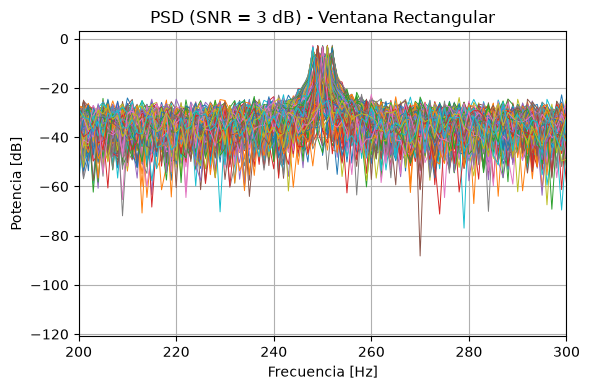

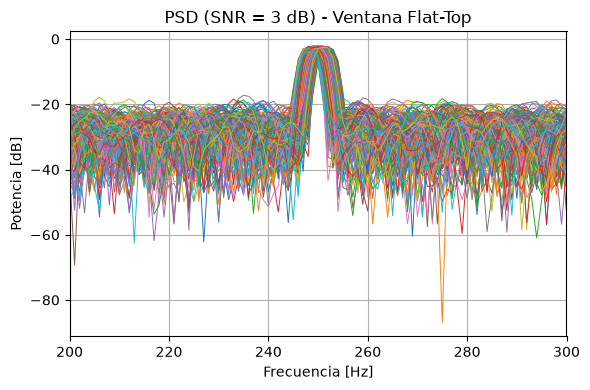

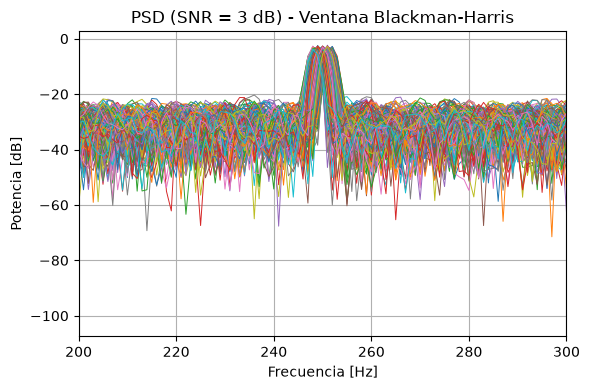

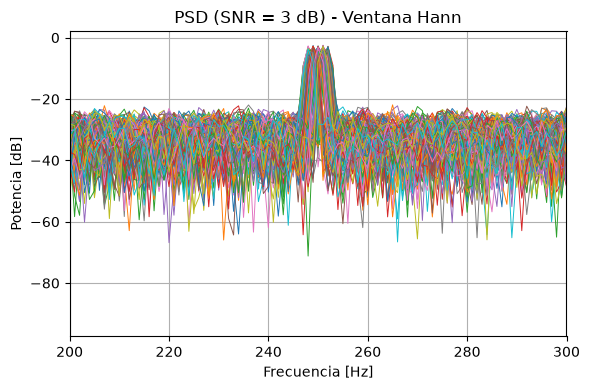

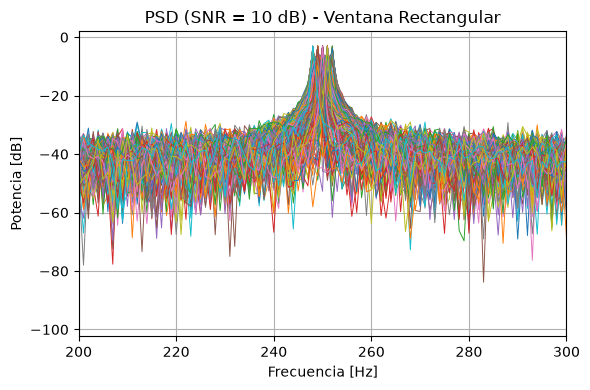

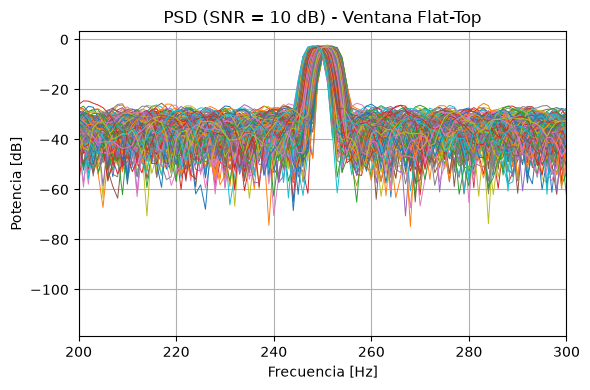

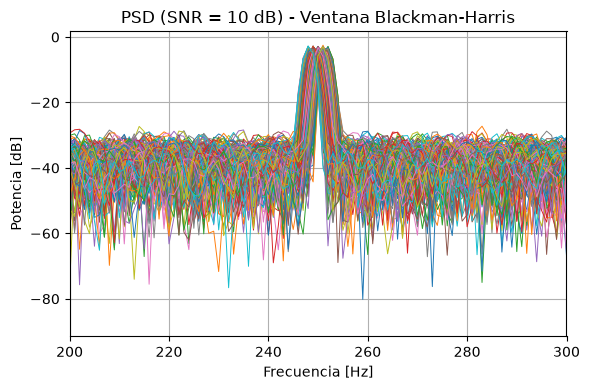

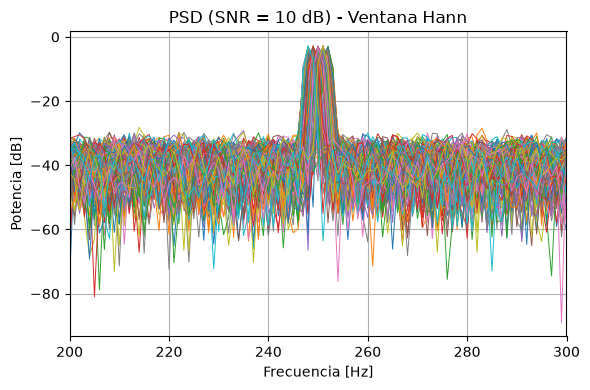

In [10]:
#%% GRÁFICOS DE PSD

frecuencias = np.arange(N) * (fs / N)
f_central = 250  
margen = 50  

# PSD para SNR bajo (3 dB)
for nombre, X in fft_3dB.items():
    plt.figure(figsize=(6, 4))
    plt.plot(frecuencias, 10 * np.log10(np.abs(X)**2 + 1e-12), lw=0.7)
    plt.title(f"PSD (SNR = 3 dB) - Ventana {nombre}")
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("Potencia [dB]")
    plt.xlim(f_central - margen, f_central + margen)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# PSD para SNR alto (10 dB)
for nombre, X in fft_10dB.items():
    plt.figure(figsize=(6, 4))
    plt.plot(frecuencias, 10 * np.log10(np.abs(X)**2 + 1e-12), lw=0.7)
    plt.title(f"PSD (SNR = 10 dB) - Ventana {nombre}")
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("Potencia [dB]")
    plt.xlim(f_central - margen, f_central + margen)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

<h4><font color='#950753'><b>Análisis</b></font></h4>

$\quad$ Del análisis visual de las 200 realizaciones de PSD superpuestas:

$\quad$ Lo único trascendental que nos permite observar y analizar es el piso de ruido y pico: se observa claramente la banda de ruido de fondo (que sube de nivel al pasar de 10 dB a 3 dB) y cómo el pico espectral a 250 Hz emerge siempre por encima del piso de ruido en todas las realizaciones. Más allá de esto, resulta un gráfico es ilustrativo; para analizar cuantitativamente la varianza, el sesgo y la dispersión exacta de cada ventana, las tablas numéricas y los histogramas son herramientas mucho más determinantes.

<h4><font color='#ba5653'> HISTOGRAMAS </font></h4>

<h4><font color='#ba5653'> Histograma de Amplitud </font></h4>

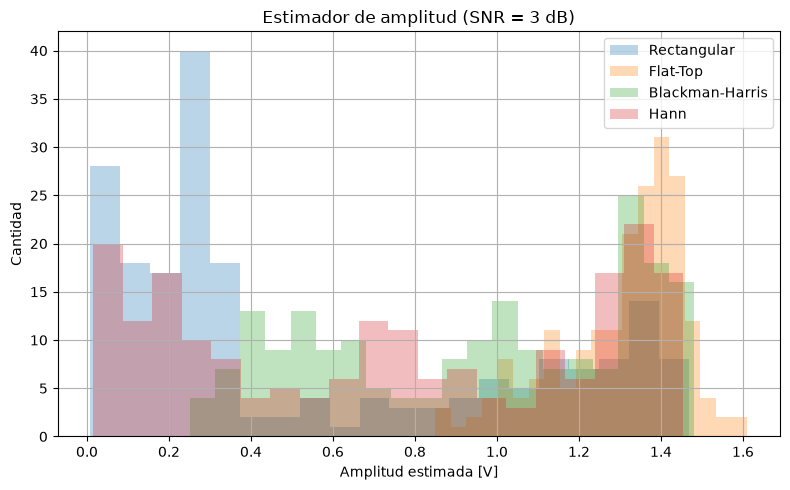

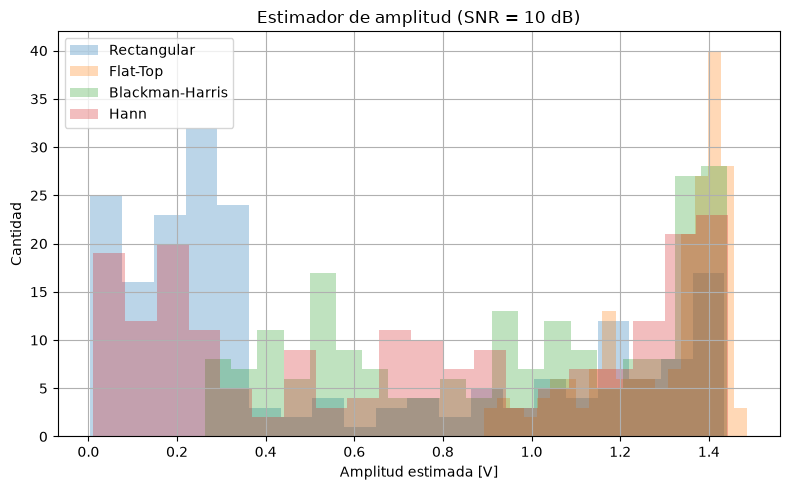

In [11]:
#%% HISTOGRAMAS

estilos = {
    "Rectangular": {"histtype": "stepfilled", "alpha": 0.3},
    "Flat-Top": {"histtype": "stepfilled", "alpha": 0.3},
    "Blackman-Harris": {"histtype": "stepfilled", "alpha": 0.3},
    "Hann": {"histtype": "stepfilled", "alpha": 0.3}
}

# Amplitud (SNR = 3 dB)
plt.figure(figsize=(8,5))
for nombre, amps in estimaciones_a1_3dB.items():
    plt.hist(amps, bins=20, label=nombre, **estilos[nombre])
plt.title("Estimador de amplitud (SNR = 3 dB)")
plt.xlabel("Amplitud estimada [V]")
plt.ylabel("Cantidad")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Amplitud (SNR = 10 dB)
plt.figure(figsize=(8,5))
for nombre, amps in estimaciones_a1.items():
    plt.hist(amps, bins=20, label=nombre, **estilos[nombre])
plt.title("Estimador de amplitud (SNR = 10 dB)")
plt.xlabel("Amplitud estimada [V]")
plt.ylabel("Cantidad")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<h4><font color='#950753'><b>Análisis</b></font></h4>

$\quad$ Al analizar los histogramas del estimador de amplitud para las distintas ventanas:

* **Ancho de banda y captura de energía:** La estabilidad del estimador depende directamente del ancho de banda del lóbulo principal de la ventana. Si la ventana tiene un lóbulo ancho (como **Flat-Top**), logra "agarrar toda la energía" de la senoidal sin importar la desintonía $f_r$, concentrando las estimaciones en un pico muy alto cerca de la amplitud verdadera ($\sqrt{2} \approx 1.414\text{ V}$).
* **Hann y Blackman-Harris (Casos intermedios):** Funcionan como soluciones de compromiso. **Blackman-Harris** (verde), al tener un lóbulo más ancho que Hann, logra acumular más estimaciones cerca de $1.4\text{ V}$. **Hann** (rojo), al tener un lóbulo más fino, sufre más pérdida por *scalloping loss*, desparramando sus mediciones hacia amplitudes intermedias.
* **Comportamiento de la ventana Rectangular:** Al tener un lóbulo principal muy fino, la ventana Rectangular es poco robusta frente a la desintonía. Apenas la frecuencia oscila fuera del centro del bin, pierde energía rápidamente y las estimaciones "se caen" hacia amplitudes muy bajas, mostrando un histograma muy disperso y sesgado hacia abajo.
* **Criterio de diseño (Sesgo vs. Varianza):** En la práctica **es preferible tener un estimador con sesgo pero con baja varianza** (como Flat-Top). El sesgo es determinístico y se puede corregir fácilmente mediante calibración (escalando las mediciones), mientras que la varianza (dispersión) refleja una incerteza aleatoria que no se puede eliminar.

**Efecto de la SNR (10 dB vs. 3 dB):** Al reducir la SNR de $10\text{ dB}$ a $3\text{ dB}$, se observa un ensanchamiento generalizado en los histogramas. El mayor nivel de ruido gaussiano suma fluctuaciones aleatorias sobre la senoidal, haciendo que las alturas de los picos bajen y se desparramen más (incluso provocando que algunas estimaciones superen los $1.414\text{ V}$ por picos constructivos de ruido).

<h4><font color='#ba5653'> Histograma de Frecuencia </font></h4>

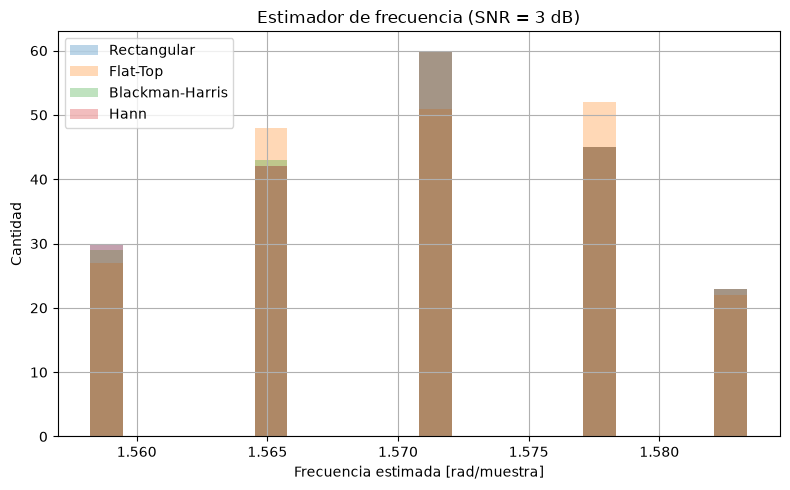

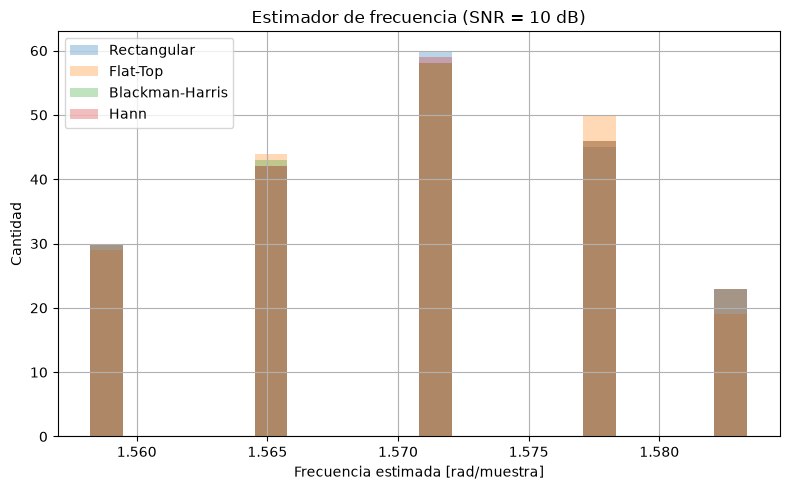

In [13]:
# Frecuencia (SNR = 3 dB)
plt.figure(figsize=(8,5))
for nombre, frecs in estimaciones_w1_3dB.items():
    plt.hist(frecs, bins=20, label=nombre, **estilos[nombre])
plt.title("Estimador de frecuencia (SNR = 3 dB)")
plt.xlabel("Frecuencia estimada [rad/muestra]")
plt.ylabel("Cantidad")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Frecuencia (SNR = 10 dB)
plt.figure(figsize=(8,5))
for nombre, frecs in estimaciones_w1.items():
    plt.hist(frecs, bins=20, label=nombre, **estilos[nombre])
plt.title("Estimador de frecuencia (SNR = 10 dB)")
plt.xlabel("Frecuencia estimada [rad/muestra]")
plt.ylabel("Cantidad")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<h4><font color='#950753'><b>Análisis</b></font></h4>

$\quad$ Al analizar los histogramas del estimador de frecuencia para las distintas ventanas:

* **Independencia del tipo de ventana:** Es posible deducir que el estimador de frecuencia no depende fuertemente de la ventana empleada. Como los lóbulos principales de todas las ventanas son simétricos respecto a su centro, el estimador por argmax resulta robusto y no presenta sesgos diferenciales entre ventanas.
* **Agrupamiento discreto en barras:** En los gráficos se ve claramente cómo las estimaciones de las cuatro ventanas caen exactamente sobre los mismos casilleros. Esto confirma que la dispersión está dominada por el salto discreto entre bins de la FFT ($\Delta f = 1\text{ Hz}$) y no por la ventana elegida.
* **Robustez ante el ruido (10 dB vs 3 dB):** El estimador demuestra ser muy robusto ante el soplo de ruido. Aunque se reduzca la SNR a 3 dB, la masa principal de estimaciones se mantiene firme alrededor del bin central y sus vecinos inmediatos, sin dispersarse a lo largo del espectro.

## Conclusión



$\quad$ A lo largo de esta TS4 analizamos el comportamiento estadístico (sesgo y varianza) de los estimadores de amplitud y frecuencia mediante simulaciones Montecarlo ($200$ realizaciones) bajo distintas ventanas y niveles de ruido:

1. **Amplitud y Frecuencia:** Se comprobó que no existe una ventana ideal para todos los casos. Si el objetivo prioritario es estimar la **amplitud** con precisión frente a la desintonía, la ventana **Flat-Top** es la mejor opción por su lóbulo principal chato que minimiza el *scalloping loss*. Si se busca resolución en **frecuencia**, la ventana **Rectangular** (o Hann) resulta mejor por tener un lóbulo principal angosto.
2. **Criterio de Sesgo vs. Varianza:** Se constató una premisa clave del laboratorio: en la práctica **es preferible contar con un estimador que tenga cierto sesgo pero baja varianza** (como Flat-Top o Blackman-Harris). El sesgo es determinístico y se puede corregir mediante calibración (escalando las mediciones), mientras que la varianza representa la incerteza estocástica que introduce el ruido y la desintonía, la cual no se puede eliminar.
3. **Pared de resolución en frecuencia:** Se demostró que la incertidumbre en la estimación de frecuencia mediante el pico máximo ($\text{argmax}$) no está limitada por el ruido ni por el tipo de ventana, sino por la cuantización discreta de la grilla de la FFT ($\Delta f = 1\text{ Hz}$). Para superar este límite de resolución sería necesario aplicar técnicas de interpolación o refinamiento como *Zero-Padding*.


## Bibliografía
> Holton, T. (2021). Digital Signal Processing: Principles and Applications. Cambridge University Press.<br>
> Lyons, R. G. (2011). Understanding Digital Signal Processing (3rd ed.). Prentice Hall.<br>
> Downey, A. B. (2016). Think DSP: Digital Signal Processing in Python. O'Reilly Media.<br>
> Porat, B. (1997). A Course in Digital Signal Processing. John Wiley & Sons.<br>
> Hayes, M. H. (1996). Statistical Digital Signal Processing and Modeling. John Wiley & Sons.